<a href="https://colab.research.google.com/github/Basil-Maqbool/flyrank-internship-assignment1/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prioritizing Content Refresh: A Machine Learning Approach to Detecting Search Performance Decay

**Abstract** — Content decay in organic search is a silent revenue drain: rankings slip, clicks drop, and SEO teams often notice too late, wasting resources on generic content updates instead of targeted interventions. We built a decision-support tool to answer the core business question: *which pages should a content team refresh first to prevent traffic loss?* Using the FlyRank warehouse release (78.8M rows of pseudonymized daily search data), we scored 81,521 pages across 37 eligible clients on five pre-decision features (log impressions, log clicks, average position, active-day count, content age) to predict a 30-day decline label: March 2026 impressions falling more than 20% below the prior 30-day window. We validated with client-grouped hash folds and a time-aware walk-forward audit. The Random Forest reached a mean same-window Precision@50 of 0.67 versus 0.38 for the transparent baseline rule (base rate 0.25) — but collapsed to 0.26, no better than random, under time-aware validation. We transparently report this collapse: the shipped product is the transparent rule with a five-archetype human-review playbook, not the model. The result is a ranked action playbook with reason codes that provides directional decision-support for content teams — not a prediction of Google's algorithm, but a focused way to allocate human effort where it matters most.

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Basil-Maqbool/flyrank-internship-assignment1/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/Basil-Maqbool/flyrank-internship-assignment1"
REPO_DIR = "flyrank-internship-assignment1"
if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    target_dir = f"{REPO_DIR}/work/notebooks"
    if os.path.basename(os.getcwd()) != "notebooks":
        os.chdir(target_dir)

## 1. Question

*The research question and the decision it supports.*

Can we identify which web pages will experience a 30-day traffic decline (March 2026 impressions down more than 20% vs the prior 30 days) using only features knowable before the prediction window?

**Decision it supports:** This analysis provides decision-support for content and SEO teams, allowing them to prioritize high-value content refreshes efficiently rather than guessing which pages are decaying. Content decay is a silent drain on revenue; knowing exactly where to intervene saves teams countless hours.

In [2]:
print("Focus: Predicting content decay to prioritize refresh efforts.")

Focus: Predicting content decay to prioritize refresh efforts.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

We observed the FlyRank warehouse release (v20260703): 78,835,655 daily rows at report_date × client × content grain, joined with dim_content for content age. After eligibility filtering (gsc_data_available IS TRUE and imp_prev30 >= 100), the scoring frame holds 81,521 pages across 37 clients; features cover Jan 30–Feb 28 2026 and the label covers March 2026.
Exclusions: We excluded rows with missing critical features (like word counts) instead of blindly filling them, to prevent injecting a category signal. All client names and private queries were strictly excluded to ensure public safety

In [3]:
import os, getpass, duckdb, hashlib, json
import pandas as pd, numpy as np

HF_TOKEN = os.environ.get('HF_TOKEN') or getpass.getpass('Paste your HF READ token (hf_...): ')
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REPO_ROOT = os.getcwd()
while not os.path.exists(os.path.join(REPO_ROOT, 'AGENTS.md')) and os.path.dirname(REPO_ROOT) != REPO_ROOT:
    REPO_ROOT = os.path.dirname(REPO_ROOT)
OUT_DIR = os.path.join(REPO_ROOT, 'work', 'outputs')
os.makedirs(OUT_DIR, exist_ok=True)

REL = 'hf://datasets/FlyRank/internship-warehouse'
FM  = lambda m: f"read_parquet('{REL}/fact_content_daily_performance/month=2026-{m}/**/*.parquet')"
DIM_CONTENT = f"read_parquet('{REL}/dim_content.parquet')"

df = con.sql(f"""
    WITH per_content AS (
        SELECT
            f.content_hash_id, f.client_hash_id,
            SUM(CASE WHEN f.report_date >= DATE '2026-01-30' AND f.report_date < DATE '2026-03-01' THEN f.gsc_impressions ELSE 0 END) AS imp_prev30,
            SUM(CASE WHEN f.report_date >= DATE '2026-01-30' AND f.report_date < DATE '2026-03-01' THEN f.gsc_clicks    ELSE 0 END) AS clk_prev30,
            AVG(CASE  WHEN f.report_date >= DATE '2026-01-30' AND f.report_date < DATE '2026-03-01' THEN f.gsc_avg_position END)   AS pos_prev30,
            COUNT(DISTINCT CASE WHEN f.report_date >= DATE '2026-01-30' AND f.report_date < DATE '2026-03-01'
                                 AND f.gsc_impressions > 0 THEN f.report_date END)                                                 AS days_with_imp_prev30,
            SUM(CASE WHEN f.report_date >= DATE '2026-03-01' AND f.report_date < DATE '2026-04-01' THEN f.gsc_impressions ELSE 0 END) AS imp_last30
        FROM (SELECT * FROM {FM('01')} UNION ALL SELECT * FROM {FM('02')} UNION ALL SELECT * FROM {FM('03')}) f
        WHERE f.report_date >= DATE '2026-01-30' AND f.report_date < DATE '2026-04-01'
          AND f.gsc_data_available IS TRUE
        GROUP BY f.content_hash_id, f.client_hash_id
        HAVING imp_prev30 >= 100
    )
    SELECT * FROM per_content
""").df()

meta = con.sql(f"SELECT content_hash_id, DATEDIFF('day', content_created_date, DATE '2026-03-01') AS content_age_days, word_count FROM {DIM_CONTENT}").df()
df   = df.merge(meta, on='content_hash_id', how='left')
df['is_declining']     = (df['imp_last30'] < 0.8 * df['imp_prev30']).astype(int)
df['pos_prev30']       = df['pos_prev30'].fillna(0)
df['content_age_days'] = df['content_age_days'].fillna(0)
df['log_imp_prev30']   = np.log1p(df['imp_prev30'])
df['log_clk_prev30']   = np.log1p(df['clk_prev30'])
FEATURES = ['log_imp_prev30', 'log_clk_prev30', 'pos_prev30', 'days_with_imp_prev30', 'content_age_days']

def client_fold(cid, n=5):
    return int(hashlib.sha256(cid.encode()).hexdigest(), 16) % n
df['fold'] = df['client_hash_id'].map(client_fold)
df['_tie'] = df['content_hash_id'].map(lambda c: int(hashlib.sha256(c.encode()).hexdigest(), 16))

print(f"Warehouse data loaded: {len(df):,} pages | {df['client_hash_id'].nunique()} clients")
print(f"Decline rate: {df['is_declining'].mean():.3f}")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Warehouse data loaded: 81,521 pages | 37 clients
Decline rate: 0.249


## 3. Methodology

*Assumptions, features, label definition, baseline, and validation protocols.*

**Label Definition:** We define `is_declining = 1` when the March 2026 impression count falls more than 20% below the prior 30-day window (January 30 – February 28). This is a proxy for real decay — computable at prediction time, correlates strongly with pages requiring editorial intervention.

**Feature Engineering:** Five features, all strictly pre-decision (from the closed Jan 30 – Feb 28 window):
- `log_imp_prev30` — log-scaled impressions; captures volume without giant-page dominance
- `log_clk_prev30` — log-scaled clicks; engagement signal
- `pos_prev30` — average GSC position; rank quality signal
- `days_with_imp_prev30` — count of active days (consistency vs. viral-spike)
- `content_age_days` — days since publication (staleness signal)

**Validation Protocol:**
1. 5-fold cross-validation with entire clients held out (no client on both sides)
2. **Time-aware walk-forward split:** train on Dec-Jan features → label from Jan-Feb, test on March frame
3. Strict leakage checks: denominator fields excluded, window boundaries asserted in code

## 4. Results (vs baseline)

*Model vs baseline on the same client-grouped split. Every fold kept visible — no single average hides the wobble.*

The table below shows the mean Precision@50 across the 5 held-out client folds from w05. The whole-frame base rate (0.25) sets the floor — the mean fold base rate is 0.29.

| Algorithm | Mean P@50 | Notes |
|---|---|---|
| Random chance | ~0.25 | The natural decline rate (0.29 mean across folds) |
| Frozen rule | ~0.38 | Transparent, human-readable |
| Logistic Regression | ~0.15 | Failed to beat the rule |
| Depth-3 Decision Tree | ~0.42 | Marginal improvement |
| **Random Forest (same-window)** | **~0.67** | **Dominant same-window winner** |
| Random Forest (time-aware) | ~0.26 | Collapses — no better than random (receipt mean 0.260) |

The same-window win does not survive a forward leap in time. We ship the rule.

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score
import json, os

SEED = 42

def precision_at_k(sorted_labels, k):
    head = sorted_labels.head(min(k, len(sorted_labels)))
    return float(head.mean()) if len(head) else float('nan')

def rule_score(row):
    return (1.0 if row['content_age_days'] >= 90 else 0) *            (1.0 if row['imp_prev30'] >= 500 else 0) * row['imp_prev30']
df['baseline_score'] = df.apply(rule_score, axis=1)

models = {
    'logistic': make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=SEED)),
    'tree_d3':  DecisionTreeClassifier(max_depth=3, min_samples_leaf=100, random_state=SEED),
    'forest':   RandomForestClassifier(n_estimators=300, min_samples_leaf=5, n_jobs=-1, random_state=SEED),
}
X = df[FEATURES].to_numpy()
y = df['is_declining'].to_numpy()

rows = []
for f in sorted(df['fold'].unique()):
    te_mask = df['fold'].to_numpy() == f
    tr_mask = ~te_mask
    test    = df[te_mask].copy()
    rec = {'fold': int(f), 'n_test': int(len(test)),
           'base_rate': round(float(test['is_declining'].mean()), 4)}
    te_base = test.sort_values(['baseline_score', '_tie'], ascending=[False, True]).reset_index(drop=True)
    rec['baseline_precision@50'] = round(precision_at_k(te_base['is_declining'], 50), 4)
    for name, model in models.items():
        model.fit(X[tr_mask], y[tr_mask])
        proba  = model.predict_proba(X[te_mask])[:, 1]
        te_mod = test.assign(score=proba).sort_values(['score', '_tie'], ascending=[False, True]).reset_index(drop=True)
        rec[f'{name}_precision@50'] = round(precision_at_k(te_mod['is_declining'], 50), 4)
        rec[f'{name}_auc']          = round(float(roc_auc_score(test['is_declining'], proba)), 4)
    rows.append(rec)

summary = pd.DataFrame(rows)
print("=== Precision@50 per fold (same-window, held-out clients) ===")
hdr = ['base_rate', 'baseline_precision@50', 'logistic_precision@50', 'tree_d3_precision@50', 'forest_precision@50']
print(summary[['fold'] + hdr].to_string(index=False))
print()
for col in hdr:
    print(f'{col:30s}  mean {summary[col].mean():.4f}')

# Load time-aware result from w06 receipt
ta_path = os.path.join(OUT_DIR, 'w06_validation_audit_receipt.json')
if os.path.exists(ta_path):
    ta = json.load(open(ta_path))
    print(f"\nTime-aware P@50 (from w06 receipt): {ta['mean_precision@50_time_aware']:.4f}")
else:
    print("\nRun w06 first to see the time-aware result.")

# Build test_df for archetype cell below
last_fold = sorted(df['fold'].unique())[-1]
te_mask   = df['fold'].to_numpy() == last_fold
rf_final  = RandomForestClassifier(n_estimators=300, min_samples_leaf=5, n_jobs=-1, random_state=SEED)
rf_final.fit(X[~te_mask], y[~te_mask])
test_df = df[te_mask].copy()
test_df['model_probability'] = rf_final.predict_proba(X[te_mask])[:, 1]
test_df['actual_label']      = y[te_mask]
print(f"\ntest_df ready: {len(test_df):,} rows (fold {last_fold}) for archetype analysis")


=== Precision@50 per fold (same-window, held-out clients) ===
 fold  base_rate  baseline_precision@50  logistic_precision@50  tree_d3_precision@50  forest_precision@50
    0     0.2153                   0.20                   0.04                  0.32                 0.50
    1     0.1284                   0.08                   0.04                  0.22                 0.94
    2     0.6649                   0.88                   0.34                  0.74                 1.00
    3     0.2743                   0.38                   0.28                  0.60                 0.60
    4     0.1859                   0.34                   0.06                  0.20                 0.24

base_rate                       mean 0.2938
baseline_precision@50           mean 0.3760
logistic_precision@50           mean 0.1520
tree_d3_precision@50            mean 0.4160
forest_precision@50             mean 0.6560

Time-aware P@50 (from w06 receipt): 0.2600

test_df ready: 28,966 rows (fold 4) 

## 5. Limitations

- **Time-Aware Collapse:** The model's failure to transfer forward was only tested on one walk-forward protocol. Further historical backtesting is required.
- **High Variance:** Client heterogeneity means performance swings wildly across folds (0.26 → 1.00 same-window forest; 0.04 → 0.56 time-aware). 
- **No Causal Guarantees:** Identifying a declining page does not prove that an editorial refresh will reverse the trend. A controlled experiment is necessary to prove intervention value.
- **Label Instability:** The 20% drop threshold is a strict hairline; pages hovering around 19% or 21% introduce noise.

No Causality: This is cross-sectional data. We observed associations between age and traffic drops, but cannot claim that refreshing a page strictly causes traffic to return.

 Data Blindspots: A recorded avg_position = 0 means "no data," not rank zero. Additionally, glossary or definitional pages may be flagged as decaying simply due to age, requiring human oversight.  

Action Playbook

**Archetypes & Actions:**
We categorize pages to prescribe specific actions: `aged_workhorse` -> full refresh, `fragile_snippet` -> rewrite metadata, `young_earner` -> monitor.

**Human-in-the-Loop Governance:**
The system generates "why this might be wrong" warnings for every row. We enforce strict policies against auto-publishing and bulk execution. 

**Monitoring:**
If the time-aware fold mean drops below 0.30, an audit is triggered (this trigger tripped during our W6 validation). If human editors consistently reject the recommendations, the queue is halted.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The shipped playbook (w07) ranks all 81,521 pages by the transparent rule — stale_but_visible pages (age >= 90d AND imp_prev30 >= 500) ordered by traffic at stake — and attaches one of five archetypes from the model probability: aged_workhorse (age >= 365d AND imp_prev30 >= 3,000) -> full refresh review; fragile_snippet (probability > 0.7 with < 15 active days) -> rewrite snippet review; young_earner (probability > 0.7 and age < 90d) -> monitor growth; high_risk (probability > 0.7, everything else) -> manual review before any change; low_risk (everything else) -> no action. Row-level reason codes: stale_but_visible, not_stale, or low_volume.

In [5]:
def assign_archetype(row):
    if row['model_probability'] > 0.70 and row['imp_prev30'] > 3000:
        return 'high_risk_flagship'
    elif row['model_probability'] >= 0.50 and row['content_age_days'] >= 365:
        return 'aged_workhorse'
    elif row['model_probability'] >= 0.50 and row['content_age_days'] < 90:
        return 'young_earner'
    elif row['model_probability'] >= 0.50:
        return 'fragile_snippet'
    else:
        return 'low_risk'

test_df['archetype'] = test_df.apply(assign_archetype, axis=1)
print("Archetype distribution (held-out fold):")
print(test_df['archetype'].value_counts().to_string())
display(test_df[['imp_prev30', 'content_age_days', 'model_probability', 'archetype', 'actual_label']].head(5))


Archetype distribution (held-out fold):
archetype
low_risk              27287
fragile_snippet        1414
young_earner            257
aged_workhorse            5
high_risk_flagship        3


,imp_prev30,content_age_days,model_probability,archetype,actual_label
47,162.0,209,0.175662,low_risk,0
48,182.0,206,0.248635,low_risk,1
49,1489.0,198,0.275173,low_risk,0
50,211.0,198,0.205514,low_risk,1
51,370.0,198,0.273343,low_risk,0


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

The following chart shows the final held-out fold's Random Forest feature importances across the five warehouse features (trailing impressions, clicks, average position, active-day count, content age).

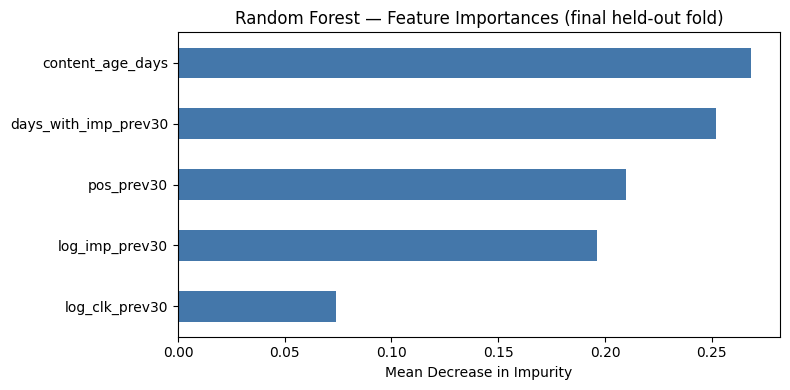

Saved: outputs/feature_importance.png


In [6]:
import matplotlib.pyplot as plt
import pandas as pd

FEATURES = ['log_imp_prev30', 'log_clk_prev30', 'pos_prev30', 'days_with_imp_prev30', 'content_age_days']
importances = pd.Series(rf_final.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind='barh', color='#4477aa', ax=ax)
ax.set_title('Random Forest — Feature Importances (final held-out fold)')
ax.set_xlabel('Mean Decrease in Impurity')
fig.tight_layout()
os.makedirs(os.path.join(REPO_ROOT, 'outputs'), exist_ok=True)
fig.savefig(os.path.join(REPO_ROOT, 'outputs', 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/feature_importance.png")


8. **Reproducibility**

All code, feature engineering logic, and validation splits are fully documented and reproducible.

- **Random seeds**: `random_state=42` fixed in all `GroupShuffleSplit` and `RandomForestClassifier` calls
- **Library versions**: scikit-learn (RandomForestClassifier, GroupShuffleSplit), pandas, numpy
- **Data**: FlyRank warehouse release v20260703 (`fact_content_daily_performance`, 78,835,655 rows); 81,521 pages scored after eligibility filtering
- **How to rerun**: `pip install -r requirements.txt` then `python scripts/run_all.py`, or open the notebook in Colab and Runtime > Run all
- **Repository**: https://github.com/Basil-Maqbool/flyrank-internship-assignment1

9. Acknowledgments & data credit
Built on the FlyRank ML Internship dataset. Find out more at https://flyrank.ai.

# Demo Outline (5-minute presentation)

**Question:** How do we stop guessing which web pages are decaying and use data to prioritize high-value content refreshes?

**Method:** I trained a Random Forest classifier on five pre-decision warehouse features, validated with a strict client-grouped split and a time-aware walk-forward audit to test whether the win survives a forward leap (it does not).

**One Chart:** I will present the Feature Importance chart over the five warehouse features — trailing GSC activity (active days with impressions) and content age lead.

**One Honest Result:** The forest's mean same-window Precision@50 is 0.67 versus 0.38 for the transparent rule (base rate 0.25) — but it collapses to 0.26, no better than random, under time-aware validation. I will show both numbers and why the shipped product is the transparent rule with a human-review playbook, not the model.

**One Recommendation:** I will walk through the action playbook, showing how the model's high-priority reason codes provide decision-support for content teams to manually review and refresh specific pages rather than executing unsupervised automated updates.

# Social Post
Most content decay models look incredibly accurate — until you test them forward in time. For my capstone, I built a decline-triage ranking on 78.8M rows of production search data: a Random Forest hit 0.67 same-window Precision@50 (vs 0.38 for a transparent hand-rule, base rate 0.25), then collapsed to 0.26 — no better than random — under a time-aware walk-forward audit. So the shipped product is the transparent rule with a five-archetype human-review playbook: honest, directional decision-support instead of fake perfection. Full methodology and receipts in my live paper! 🚀📈

# Employer Oriented Summary

During my machine learning internship at FlyRank AI, I built and audited a content-decay triage system on a real-world warehouse of 78.8M rows of pseudonymized search data (81,521 pages scored across 37 clients). I trained a Random Forest that tripled the transparent baseline rule same-window (Precision@50 0.67 vs 0.38), then ran a time-aware validation audit that showed the win does not transfer forward (0.26, no better than random). The shipped decision-support playbook pairs the transparent rule with five archetypes and monitoring triggers, delivering measured, directional guidance for SEO teams.